### **PRE Al AMAL 18**
PYTHON (Applications)
**By: Islam Hamama**
### 17 August 2026

# Well-logging Part

## Install Lasio Library

In [1]:
!pip install lasio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.9 MB/s eta 0:00:00


Connect to your GoogleDrive



1.   **Create new folder "Well_logging" in your GoogleDrive**
2.   **Uplaod the attached files**

In [2]:
from google.colab import drive
import os
drive.mount('/content/gdrive')
path='/content/gdrive/MyDrive/Well_logging'
os.chdir(path)

Mounted at /content/gdrive


## You can now read "15-9-19_SR_COMP.LAS" file from your drive

In [3]:
#import lasio library after installing
from lasio import read
import pandas as pd
import numpy as np
log_1 = read("15-9-19_SR_COMP.LAS")

# Well Header from LAS file

In [4]:
log_1.well

[HeaderItem(mnemonic="STRT", unit="M", value="102.1568", descr="Top Depth"),
 HeaderItem(mnemonic="STOP", unit="M", value="4636.514", descr="Bottom Depth"),
 HeaderItem(mnemonic="STEP", unit="M", value="0.1524", descr="Depth Increment"),
 HeaderItem(mnemonic="NULL", unit="", value="-999.25", descr="Null Value"),
 HeaderItem(mnemonic="FLD", unit="", value="Q15", descr="Field Name"),
 HeaderItem(mnemonic="WELL", unit="", value="15/9-19", descr="NAME"),
 HeaderItem(mnemonic="WBN", unit="", value="15/9-19 SR", descr="WELLBORE"),
 HeaderItem(mnemonic="NATI", unit="", value="NOR", descr="COUNTRY"),
 HeaderItem(mnemonic="CTRY", unit="", value="NOR", descr="COUNTRY"),
 HeaderItem(mnemonic="COMP", unit="", value="STATOIL", descr="OPERATOR"),
 HeaderItem(mnemonic="PDAT", unit="", value="MSL", descr="PERM DATUM"),
 HeaderItem(mnemonic="COUN", unit="", value="NORTH SEA", descr="RIG NAME"),
 HeaderItem(mnemonic="STAT", unit="", value="NORWAY", descr="STATE"),
 HeaderItem(mnemonic="PBWE", unit="", v

In [5]:
#Printing the items of the log with readable format
for line in log_1.well:
    print(f"{line.descr} ({line.mnemonic}): {line.value}")

Top Depth (STRT): 102.1568
Bottom Depth (STOP): 4636.514
Depth Increment (STEP): 0.1524
Null Value (NULL): -999.25
Field Name (FLD): Q15
NAME (WELL): 15/9-19
WELLBORE (WBN): 15/9-19 SR
COUNTRY (NATI): NOR
COUNTRY (CTRY): NOR
OPERATOR (COMP): STATOIL
PERM DATUM (PDAT): MSL
RIG NAME (COUN): NORTH SEA
STATE (STAT): NORWAY
PB WELL ID (PBWE): 15/9-19
PB WELLBORE ID (APIN): 15/9-19 SR
PB WELL NAME SET (PBWS): ALL


# Get the NULL value from the LAS header

In [8]:
#Printing the items of the log with readable format
for line in log_1.well:
    if line.mnemonic =='NULL':
       print(f'{line.mnemonic} Unit {line.unit} = {line.value} Desc. {line.descr}')

NULL Unit  = -999.25 Desc. Null Value


In [9]:
log_1.curves

[CurveItem(mnemonic="DEPT", unit="M", value="00 001 00 00", descr="1  DEPTH", original_mnemonic="DEPT", data.shape=(29754,)),
 CurveItem(mnemonic="AC", unit="US/F", value="", descr="2  Sonic Transit Time (Slowness)", original_mnemonic="AC", data.shape=(29754,)),
 CurveItem(mnemonic="CALI", unit="IN", value="", descr="3  Caliper", original_mnemonic="CALI", data.shape=(29754,)),
 CurveItem(mnemonic="DEN", unit="G/CC", value="", descr="4  Bulk Density", original_mnemonic="DEN", data.shape=(29754,)),
 CurveItem(mnemonic="GR", unit="GAPI", value="", descr="5  Gamma Ray", original_mnemonic="GR", data.shape=(29754,)),
 CurveItem(mnemonic="NEU", unit="%", value="", descr="6  Neutron Porosity", original_mnemonic="NEU", data.shape=(29754,)),
 CurveItem(mnemonic="RDEP", unit="OHMM", value="", descr="7  Deep Resistivity", original_mnemonic="RDEP", data.shape=(29754,)),
 CurveItem(mnemonic="RMED", unit="OHMM", value="", descr="8  Medium Resistivity", original_mnemonic="RMED", data.shape=(29754,))]

In [11]:
#Printing the curves inside the log
for curve in log_1.curves:
    print(f'{curve.mnemonic} >> Desc. {curve.descr}')

DEPT >>  1  DEPTH
AC >>  2  Sonic Transit Time (Slowness)
CALI >>  3  Caliper
DEN >>  4  Bulk Density
GR >>  5  Gamma Ray
NEU >>  6  Neutron Porosity
RDEP >>  7  Deep Resistivity
RMED >>  8  Medium Resistivity


In [12]:
for count, curve in enumerate(log_1.curves):
    print(f"No: {count} Curve: {curve.mnemonic}, Units: {curve.unit}, Description: {curve.descr}")
print(f"There are a total of: {count+1} curves present within this file")

No: 0 Curve: DEPT, Units: M, Description: 1  DEPTH
No: 1 Curve: AC, Units: US/F, Description: 2  Sonic Transit Time (Slowness)
No: 2 Curve: CALI, Units: IN, Description: 3  Caliper
No: 3 Curve: DEN, Units: G/CC, Description: 4  Bulk Density
No: 4 Curve: GR, Units: GAPI, Description: 5  Gamma Ray
No: 5 Curve: NEU, Units: %, Description: 6  Neutron Porosity
No: 6 Curve: RDEP, Units: OHMM, Description: 7  Deep Resistivity
No: 7 Curve: RMED, Units: OHMM, Description: 8  Medium Resistivity
There are a total of: 8 curves present within this file


In [13]:
well = log_1.df()#convert the lasfile to dataframe


In [15]:
well

,AC,CALI,DEN,GR,NEU,RDEP,RMED
DEPT,,,,,,,
102.1568,NaN,NaN,NaN,5.3274,NaN,NaN,NaN
102.3092,NaN,NaN,NaN,5.8235,NaN,NaN,NaN
102.4616,NaN,NaN,NaN,6.5228,NaN,NaN,NaN
102.6140,NaN,NaN,NaN,7.2285,NaN,NaN,NaN
102.7664,NaN,NaN,NaN,9.5020,NaN,NaN,NaN
...,...,...,...,...,...,...,...
4635.9044,NaN,NaN,NaN,NaN,NaN,0.7729,0.5978
4636.0568,NaN,NaN,NaN,NaN,NaN,0.8369,0.6257
4636.2092,NaN,NaN,NaN,NaN,NaN,0.8741,0.6888


In [16]:
type(well)

pandas.core.frame.DataFrame

In [17]:
well.describe()

,AC,CALI,DEN,GR,NEU,RDEP,RMED
count,7007.000000,7007.000000,7084.000000,28117.000000,7096.000000,12223.000000,12223.000000
mean,79.498714,9.611068,2.449055,71.986798,20.117166,2.438382,2.386781
std,18.390705,1.019751,0.165122,32.922780,14.729530,6.631202,5.735731
min,1.025100,6.000000,1.943000,2.766100,2.178300,0.250300,0.179000
25%,66.154350,9.142900,2.319975,50.255200,10.631350,0.988000,0.847850
50%,74.661900,9.589400,2.505600,74.998500,15.718550,1.536100,1.490800
75%,93.304550,9.904800,2.585125,92.343800,25.067375,2.434050,2.415400
max,181.813900,20.330400,3.001300,304.333700,146.347400,198.537100,168.604400


In [18]:
well.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29754 entries, 102.1568 to 4636.514
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AC      7007 non-null   float64
 1   CALI    7007 non-null   float64
 2   DEN     7084 non-null   float64
 3   GR      28117 non-null  float64
 4   NEU     7096 non-null   float64
 5   RDEP    12223 non-null  float64
 6   RMED    12223 non-null  float64
dtypes: float64(7)
memory usage: 1.8 MB


In [19]:
well_nan = well.notnull() * 1 #CONVERT BOOLEAN TO ZERO AND 1


# Plot your log and it will be saved in your GoogleDrive

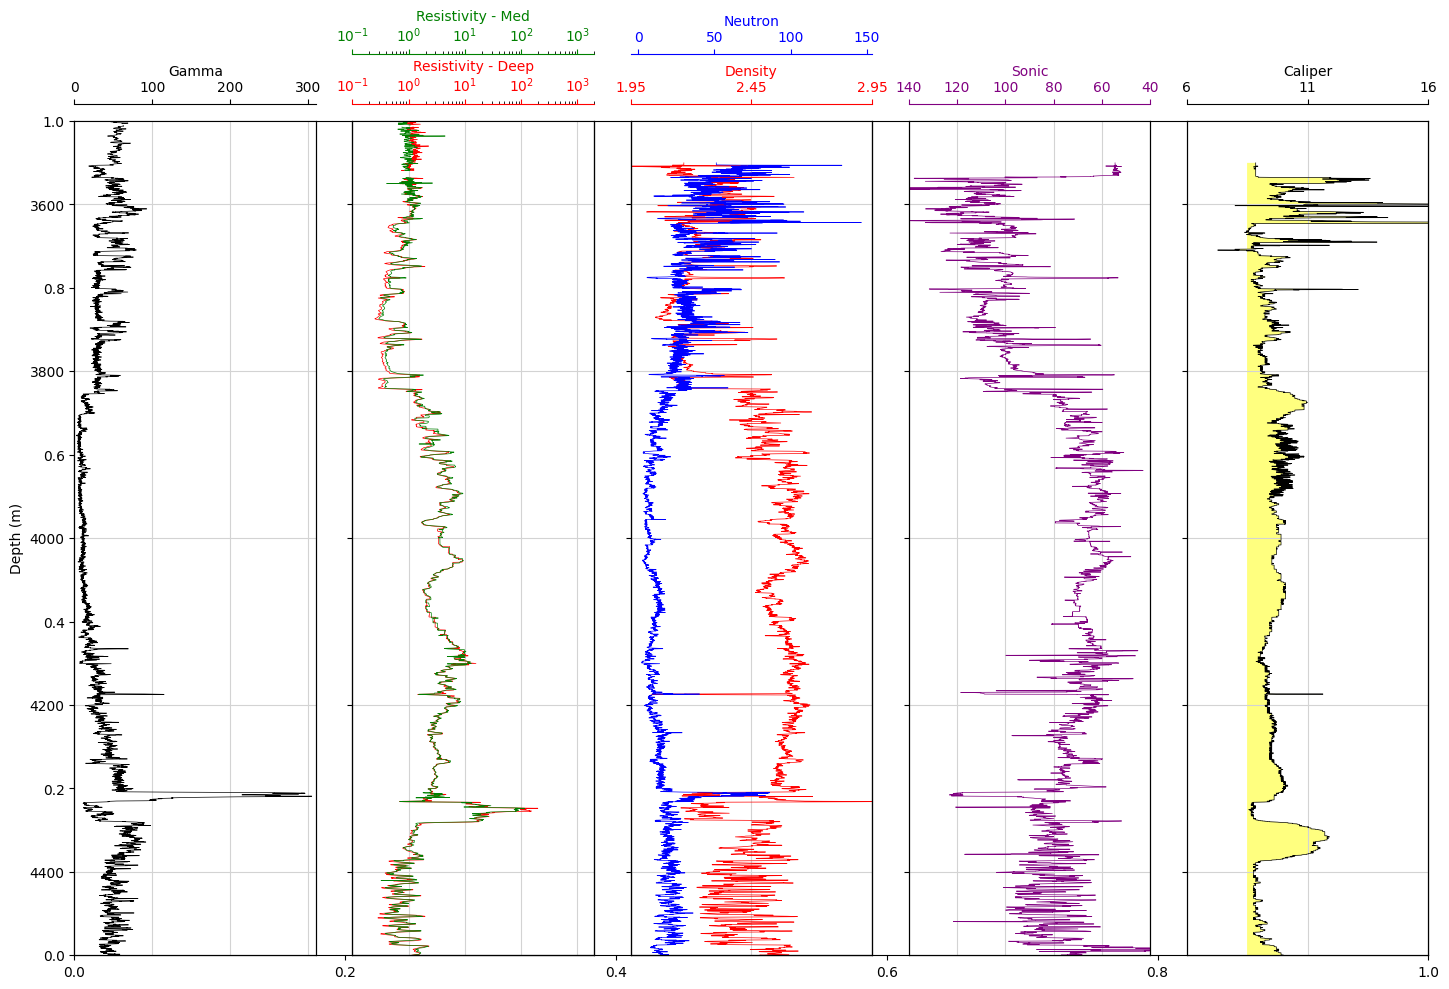

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,10))

# Set up the plot axes
ax1 = plt.subplot2grid((1,5), (0,0), rowspan=1, colspan=1)
ax2 = plt.subplot2grid((1,5), (0,1), rowspan=1, colspan=1, sharey=ax1)
ax3 = plt.subplot2grid((1,5), (0,2), rowspan=1, colspan=1, sharey=ax1)
ax4 = plt.subplot2grid((1,5), (0,3), rowspan=1, colspan=1, sharey=ax1)
ax5 = ax3.twiny()  # Neutron track on top of density
ax6 = plt.subplot2grid((1,5), (0,4), rowspan=1, colspan=1, sharey=ax1)
ax7 = ax2.twiny()  # Resistivity Med on top of Resistivity Deep

# Add top borders back
for ax_tmp in [ax1, ax2, ax3, ax4, ax6]:
    axx = ax_tmp.twiny()
    axx.xaxis.set_visible(False)

# Gamma Ray
ax1.plot(well["GR"], well.index, color="black", linewidth=0.5)
ax1.set_xlabel("Gamma")
ax1.set_xlim(0, 310)
ax1.set_ylabel("Depth (m)")
ax1.tick_params(axis='x', colors="black")
ax1.spines["top"].set_edgecolor("black")
ax1.set_xticks([0, 100, 200, 300])

# Resistivity Deep
ax2.plot(well["RDEP"], well.index, color="red", linewidth=0.5)
ax2.set_xlabel("Resistivity - Deep")
ax2.set_xlim(0.2, 2000)
ax2.set_xscale("log")
ax2.xaxis.label.set_color("red")
ax2.tick_params(axis='x', colors="red")
ax2.spines["top"].set_edgecolor("red")
ax2.set_xticks([0.1, 1, 10, 100, 1000])

# Density
ax3.plot(well["DEN"], well.index, color="red", linewidth=0.5)
ax3.set_xlabel("Density")
ax3.set_xlim(1.95, 2.95)
ax3.xaxis.label.set_color("red")
ax3.tick_params(axis='x', colors="red")
ax3.spines["top"].set_edgecolor("red")
ax3.set_xticks([1.95, 2.45, 2.95])

# Sonic
ax4.plot(well["AC"], well.index, color="purple", linewidth=0.5)
ax4.set_xlabel("Sonic")
ax4.set_xlim(140, 40)
ax4.xaxis.label.set_color("purple")
ax4.tick_params(axis='x', colors="purple")
ax4.spines["top"].set_edgecolor("purple")

# Neutron (overlay on Density)
ax5.plot(well["NEU"], well.index, color="blue", linewidth=0.5)
ax5.set_xlabel("Neutron")
ax5.xaxis.label.set_color("blue")
ax5.tick_params(axis='x', colors="blue")
ax5.spines["top"].set_position(("axes", 1.08))
ax5.spines["top"].set_visible(True)
ax5.spines["top"].set_edgecolor("blue")

# Caliper
ax6.plot(well["CALI"], well.index, color="black", linewidth=0.5)
ax6.set_xlabel("Caliper")
ax6.set_xlim(6, 16)
ax6.xaxis.label.set_color("black")
ax6.tick_params(axis='x', colors="black")
ax6.spines["top"].set_edgecolor("black")
ax6.fill_betweenx(well.index, 8.5, well["CALI"], facecolor="yellow", alpha=0.5)
ax6.set_xticks([6, 11, 16])

# Resistivity Med (overlay on Resistivity Deep)
ax7.plot(well["RMED"], well.index, color="green", linewidth=0.5)
ax7.set_xlabel("Resistivity - Med")
ax7.set_xlim(0.2, 2000)
ax7.set_xscale("log")
ax7.xaxis.label.set_color("green")
ax7.spines["top"].set_position(("axes", 1.08))
ax7.spines["top"].set_visible(True)
ax7.tick_params(axis='x', colors="green")
ax7.spines["top"].set_edgecolor("green")
ax7.set_xticks([0.1, 1, 10, 100, 1000])

# Common formatting
for ax in [ax1, ax2, ax3, ax4, ax6]:
    ax.set_ylim(4500, 3500)
    ax.grid(which='major', color='lightgrey', linestyle='-')
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.spines["top"].set_position(("axes", 1.02))

for ax in [ax2, ax3, ax4, ax6]:
    plt.setp(ax.get_yticklabels(), visible=False)

plt.tight_layout()
fig.subplots_adjust(wspace=0.15)
fig.savefig("log_alamal18.jpg")
plt.show()


In [21]:
print(well.columns.tolist())


['AC', 'CALI', 'DEN', 'GR', 'NEU', 'RDEP', 'RMED']


# Another Example for reading "CSV" log file

In [22]:
import pandas as pd
import numpy as np
#well = pd.read_csv("15_9-19.csv", header=0, skiprows=[1])
well = pd.read_csv("B1 Digital Logs.csv", header=0, skiprows=[1])
well.describe()


,DEPTH,EGR,HDRS,ERHO,ENPH,PHIE,SWE,Unnamed: 7
count,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,1.0
mean,2200.500000,95.520735,1180.072820,7.27756,0.274695,-999.906300,-999.095595,1.0
std,57.879185,39.338199,6346.730696,70.33621,0.131384,9974.751413,9974.833099,NaN
min,2101.000000,19.610000,0.944000,1.24300,0.086000,-99999.000000,-99999.000000,1.0
25%,2150.750000,54.013500,2.409000,2.24425,0.211000,0.000000,0.986750,1.0
50%,2200.500000,104.812000,3.590500,2.39500,0.249000,0.003500,1.000000,1.0
75%,2250.250000,124.704500,12.793000,2.46225,0.299000,0.194000,1.000000,1.0
max,2300.000000,213.213000,40000.000000,997.00000,1.333000,0.555000,1.309000,1.0


# Replacing the Null values

In [23]:
well.replace(-999.25, np.nan, inplace=True)
#well.replace(-999.00, np.nan, inplace=True)
well.replace(-99999.000, np.nan, inplace=True)

In [ ]:
well=well

In [24]:
well.describe()

,DEPTH,EGR,HDRS,ERHO,ENPH,PHIE,SWE,Unnamed: 7
count,200.000000,200.000000,200.000000,200.00000,200.000000,198.000000,198.000000,1.0
mean,2200.500000,95.520735,1180.072820,7.27756,0.274695,0.084545,0.903439,1.0
std,57.879185,39.338199,6346.730696,70.33621,0.131384,0.108812,0.254461,NaN
min,2101.000000,19.610000,0.944000,1.24300,0.086000,0.000000,0.000000,1.0
25%,2150.750000,54.013500,2.409000,2.24425,0.211000,0.000000,0.989250,1.0
50%,2200.500000,104.812000,3.590500,2.39500,0.249000,0.004500,1.000000,1.0
75%,2250.250000,124.704500,12.793000,2.46225,0.299000,0.196000,1.000000,1.0
max,2300.000000,213.213000,40000.000000,997.00000,1.333000,0.555000,1.309000,1.0


In [26]:
well.head(10)


,DEPTH,EGR,HDRS,ERHO,ENPH,PHIE,SWE,Unnamed: 7
0,2101,93.905,2.472,2.517,0.281,0.0,1.0,NaN
1,2102,104.401,2.484,2.495,0.269,0.0,1.0,NaN
2,2103,106.291,2.420,2.499,0.252,0.0,1.0,NaN
3,2104,90.531,2.397,2.489,0.299,0.0,1.0,NaN
4,2105,97.280,2.413,2.491,0.304,0.0,1.0,NaN
5,2106,96.162,2.296,2.557,0.287,0.0,1.0,NaN
6,2107,106.485,2.095,2.441,0.299,0.0,1.0,NaN
7,2108,105.091,2.167,2.464,0.287,0.0,1.0,NaN
8,2109,94.874,2.193,2.492,0.284,0.0,1.0,NaN
9,2110,105.102,2.334,2.460,0.269,0.0,1.0,NaN


<Axes: >

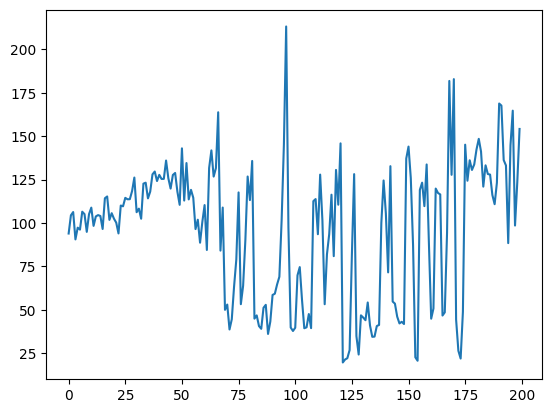

In [27]:
well['EGR'].plot()

<Axes: xlabel='ENPH', ylabel='ERHO'>

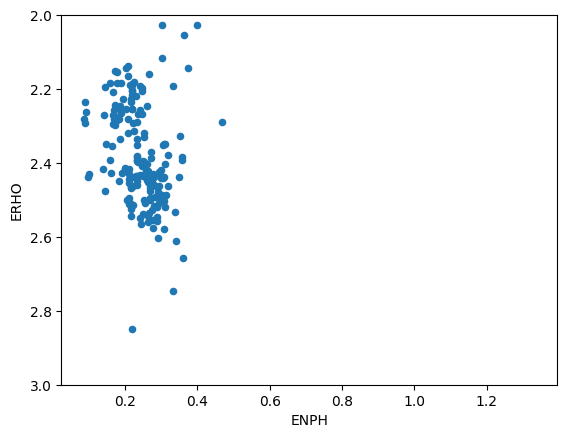

In [28]:
#Using DataFrame (Pandas)
well.plot(kind = 'scatter', x = 'ENPH', y = 'ERHO', ylim=(3, 2))

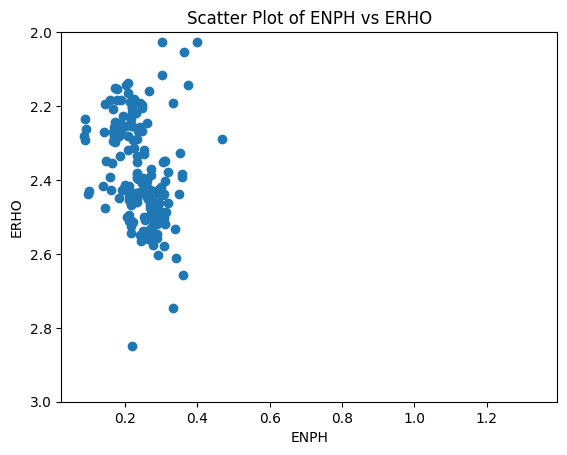

In [29]:
import matplotlib.pyplot as plt

plt.scatter(well['ENPH'], well['ERHO'])
plt.ylim(3, 2)
plt.xlabel("ENPH")
plt.ylabel("ERHO")
plt.title("Scatter Plot of ENPH vs ERHO")
plt.show()

<Axes: xlabel='ENPH', ylabel='ERHO'>

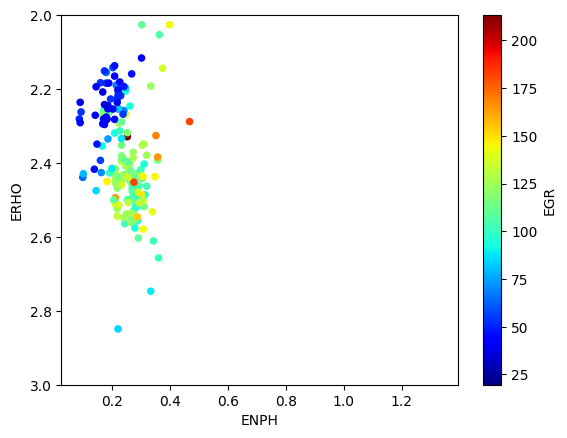

In [ ]:
well.plot(kind = 'scatter', x = 'ENPH', y = 'ERHO', c='EGR',
          colormap='jet',
          ylim=(3, 2))

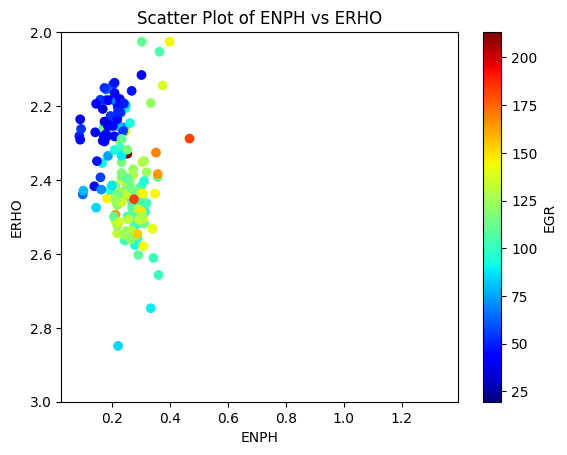

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    well['ENPH'],
    well['ERHO'],
    c=well['EGR'],      # color scale using EGR
    cmap='jet'          # colormap https://matplotlib.org/stable/users/explain/colors/colormaps.html
)
plt.ylim(3, 2)
plt.xlabel("ENPH")
plt.ylabel("ERHO")
plt.title("Scatter Plot of ENPH vs ERHO")
plt.colorbar(label="EGR")  # add colorbar for EGR
plt.show()

<Axes: ylabel='Frequency'>

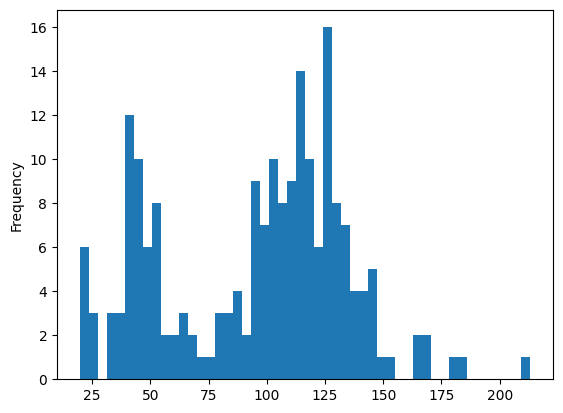

In [ ]:
well['EGR'].plot(kind="hist", bins = 50)


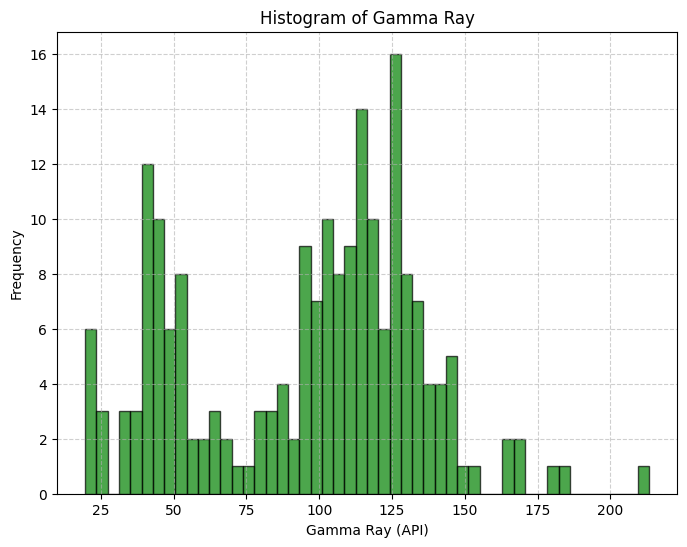

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hist(well["EGR"], bins=50, color="green", edgecolor="black", alpha=0.7)
plt.xlabel("Gamma Ray (API)")
plt.ylabel("Frequency")
plt.title("Histogram of Gamma Ray")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


<Axes: ylabel='Density'>

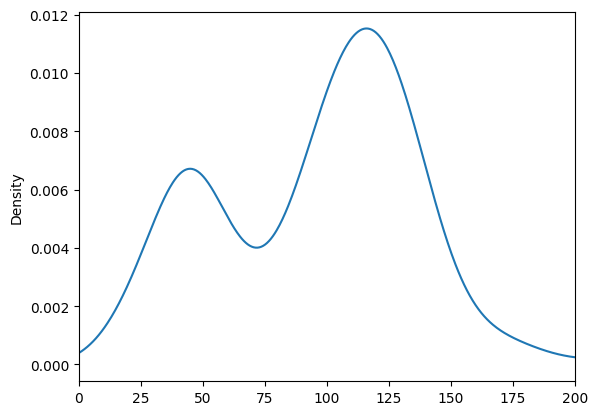

In [ ]:
well['EGR'].plot(kind="kde", xlim =(0,200))


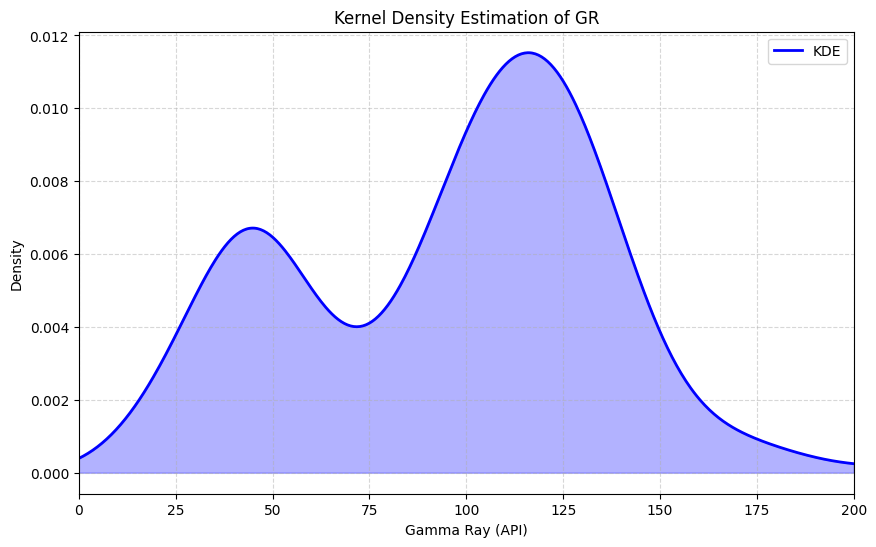

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

data = well["EGR"].dropna()

# Fit KDE
kde = gaussian_kde(data)

# Create a range for x-axis
x_vals = np.linspace(0, 200, 500)

# Evaluate the KDE on the range
y_vals = kde(x_vals)

# Plot
plt.figure(figsize=(10,6))
plt.plot(x_vals, y_vals, color="blue", linewidth=2, label="KDE")
plt.fill_between(x_vals, y_vals, alpha=0.3, color="blue")

plt.xlim(0, 200)
plt.xlabel("Gamma Ray (API)")
plt.ylabel("Density")
plt.title("Kernel Density Estimation of GR")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# Another Example of "CSV" log file

*define the header to be the 1 row on the CSV file and the second row will be skipped from*

In [ ]:
well = pd.read_csv("15_9-19.csv", header=0, skiprows=[1])


In [ ]:
well.head(20)

,DEPTH,CALI,COAL,DT,DT_LOG,DTS,DTS_LOG,GR,NPHI,PHIE,PHIEC,PHIT,PHITC,RHOB,RHOB_LOG,RT,RW,TEMP
0,3500.0183,9.315,0,76.7292,76.7292,157.1754,157.1754,36.621,0.1542,0.1122,0.1098,0.1209,0.1186,2.4602,2.460,1.791,0.0211,94.5855
1,3500.1707,9.324,0,77.2473,77.2473,158.9566,158.9566,36.374,0.1694,0.1074,0.1060,0.1159,0.1146,2.4680,2.468,1.756,0.0211,94.5897
2,3500.3231,9.338,0,77.8462,77.8462,159.7642,159.7642,30.748,0.1776,0.1082,0.1079,0.1127,0.1125,2.4730,2.473,1.720,0.0211,94.5940
3,3500.4755,9.329,0,78.3571,78.3571,158.7547,158.7547,29.795,0.1767,0.1254,0.1226,0.1292,0.1264,2.4471,2.447,1.696,0.0211,94.5982
4,3500.6279,9.328,0,78.6560,78.6560,157.1320,157.1320,27.346,0.1662,0.1278,0.1249,0.1299,0.1270,2.4460,2.446,1.697,0.0211,94.6025
5,3500.7803,9.331,0,78.7490,78.7490,155.8588,155.8588,24.997,0.1716,0.1276,0.1247,0.1280,0.1251,2.4490,2.449,1.738,0.0211,94.6067
6,3500.9327,9.333,0,78.7119,78.7119,154.3660,154.3660,20.609,0.1612,0.1090,0.1088,0.1090,0.1088,2.4789,2.479,1.813,0.0211,94.6109
7,3501.0851,9.313,0,78.5689,78.5689,153.1059,153.1059,18.349,0.1586,0.1171,0.1152,0.1171,0.1152,2.4661,2.466,1.887,0.0211,94.6152
8,3501.2375,9.327,0,78.3028,78.3028,151.6804,151.6804,16.766,0.1660,0.1286,0.1246,0.1286,0.1246,2.4481,2.448,1.924,0.0211,94.6194
9,3501.3899,9.334,0,77.9408,77.9408,150.9345,150.9345,17.086,0.1740,0.1096,0.1087,0.1096,0.1087,2.4779,2.478,1.933,0.0211,94.6236


In [ ]:
well.replace(-999, np.nan,inplace=True)

In [ ]:
well['GR'].quantile(q=0.01)

np.float64(9.26496)

In [ ]:
well['GR'].quantile(q=0.99)

np.float64(217.43692000000001)

*quinatile is much accurate in this case to avoid outlayers as shown in next plot*

<Axes: >

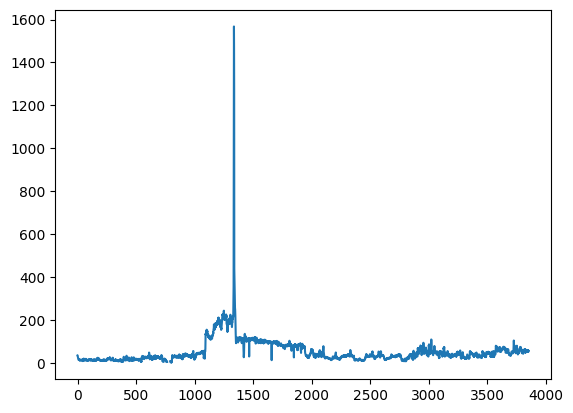

In [ ]:
well['GR'].plot()

(0.0, 250.0)

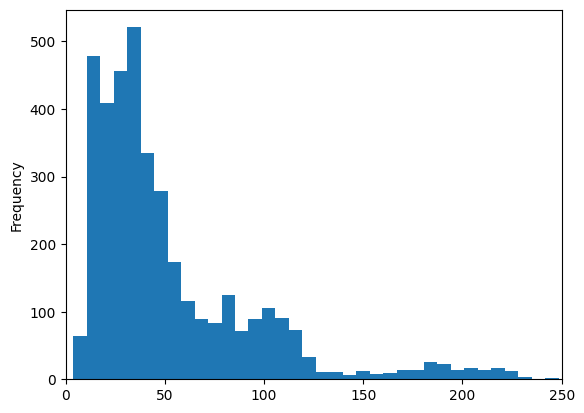

In [ ]:
well['GR'].plot(kind='hist', bins=230)
plt.xlim(0, 250)

**Prepare your needed functions for your formation evaluation and run them on the logs**

## The Math Behind the Steps (Formation Evaluation)

Shale volume: $V_{sh} = \frac{GR - GR_{min}}{GR_{max} - GR_{min}}$

Density porosity: $\phi_D = \frac{\rho_{ma} - \rho_b}{\rho_{ma} - \rho_f}$  ($\rho_{ma}=2.65$ g/cm3, $\rho_f=1.0$ g/cm3)

Effective porosity: $\phi_e = \phi_D - 0.3\,V_{sh}$

Archie water saturation: $S_w = \left( \frac{a\,R_w}{\phi^{m}\,R_t} \right)^{1/n}$  ($a=1$, $m=2$, $n=2$)

**Every symbol is a column in the DataFrame.** The code below is just these equations.

### Nomenclature — every symbol, and the column it lives in

| Symbol | Meaning | Unit | In the code |
|---|---|---|---|
| $GR$ | gamma ray | API | `well['GR']` |
| $GR_{min}$ | clean-sand baseline | API | `well['GR'].quantile(0.01)` |
| $GR_{max}$ | shale baseline | API | `well['GR'].quantile(0.99)` |
| $V_{sh}$ | shale volume | fraction (0-1) | `well['VSHALE']` |
| $\rho_b$ | bulk density | g/cm3 | `well['RHOB']` |
| $\rho_{ma}$ | matrix density | g/cm3 | `2.65` (sandstone) |
| $\rho_f$ | fluid density | g/cm3 | `1.0` (water) |
| $\phi_D$ | density (total) porosity | fraction | `well['PHI']` |
| $\phi_e$ | effective porosity | fraction | `well['PHIECALC']` |
| $S_w$ | water saturation | fraction | `well['SW_LIM']` (capped at 1) |
| $R_t$ | true (deep) resistivity | ohm.m | `well['RT']` |
| $R_w$ | formation-water resistivity | ohm.m | `well['RW']` |
| $a$ | tortuosity factor | - | `1` |
| $m$ | cementation exponent | - | `2` |
| $n$ | saturation exponent | - | `2` |
| $\Delta z$ | depth sample interval | m | `STEP = 0.1524` |

**Every fraction is a fraction** — $V_{sh}$, $\phi_D$, $\phi_e$, $S_w$ all run 0-1,
never 0-100. **And $a$, $m$, $n$ are rock properties, not constants** — they belong in
core data; 1, 2, 2 is the clean-sandstone default, so say so.

### References

- **[1]** Rider & Kennedy (2011), *The Geological Interpretation of Well Logs*, 3rd ed.
  — linear $I_{GR}$; non-linear forms in Larionov (1969), *Borehole Radiometry*.
- **[2]** Asquith & Krygowski (2004), *Basic Well Log Analysis*, AAPG Methods in
  Exploration 16 — density porosity.
- **[3]** Dewan (1983), *Essentials of Modern Open-Hole Log Interpretation* — the general
  form is $\phi_e = \phi_D - V_{sh}\,\phi_{D,shale}$; the **0.3** here is a *local*
  shale porosity, not a universal constant.
- **[4]** **Archie, G.E. (1942)**, "The Electrical Resistivity Log as an Aid in
  Determining Some Reservoir Characteristics", *Trans. AIME* **146**, 54–62 — valid for
  clean, water-wet rock; $a$, $m$, $n$ ideally come from core, not defaults.
- **[5]** Worthington & Cosentino (2005), "The Role of Cut-offs in Integrated Reservoir
  Studies", *SPE Res. Eval. & Eng.* **8**(4), 276–290 — cut-offs are project decisions.


In [ ]:
#Shale Volume from Gamma
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#(gamma_ray-gamaray_min)
def shale_volume(gamma_ray, gamma_ray_max, gamma_ray_min):
    vshale = (gamma_ray - gamma_ray_min) / (gamma_ray_max - gamma_ray_min)
    return round(vshale, 4)
#Density_Prosity
def density_porosity(input_density, matrix_density, fluid_density):
    denpor = (matrix_density - input_density) / (matrix_density - fluid_density)
    return round(denpor, 4)
#Archie water saturation
def sw_archie(porosity, rt, rw, archieA, archieM, archieN):
    sw = ((archieA / (porosity ** archieM)) * (rw/rt))**(1/archieN)
    return sw
# Another method simandoux
def sw_simandoux(phie, rt, rw, archieA, archieM, archieN, vshale, rshale):
    A = (1 - vshale) * archieA * rw / (phie ** archieM)
    B = A * vshale / (2 * rshale)
    C = A / rt

    sw = ((B **2 + C)**0.5 - B) **(2 / archieN)
    return sw
#Calculate Shale Volume
well['VSHALE'] = shale_volume(well['GR'], well['GR'].quantile(q=0.99),
                             well['GR'].quantile(q=0.01))
#Calculate density porosity
well['PHI'] = density_porosity(well['RHOB'], 2.65, 1)
#Calculate PHIE
well['PHIECALC'] = well['PHI'] - (well['VSHALE'] * 0.3)
#Calculate Archie SW
well['SW'] = sw_archie(well['PHI'], well['RT'], well['RW'], 1, 2, 2)
well['SW_SIM'] = sw_simandoux(well['PHIECALC'], well['RT'], well['RW'], 1, 2, 2, well['VSHALE'],2)
#Limit SW to 1
well['SW_LIM'] = well['SW'].mask(well['SW']>1, 1)
well['SW__SIM_LIM'] = well['SW_SIM'].mask(well['SW_SIM']>1, 1)

In [ ]:
well.describe()

,DEPTH,CALI,COAL,DT,DT_LOG,DTS,DTS_LOG,GR,NPHI,PHIE,...,RT,RW,TEMP,VSHALE,PHI,PHIECALC,SW,SW_SIM,SW_LIM,SW__SIM_LIM
count,4101.000000,3905.000000,3905.0,3905.000000,3905.000000,3905.000000,3905.000000,3817.000000,3904.000000,3842.000000,...,3905.000000,3842.000000,3905.000000,3817.000000,3902.000000,3814.000000,3842.000000,3768.000000,3842.000000,3768.000000
mean,3812.438300,8.782929,0.0,80.918894,80.918894,150.556435,150.556435,54.641506,0.213049,0.092930,...,7.325373,0.019713,102.852614,0.217976,0.122300,0.057599,1.881747,1.720901,0.787412,0.830683
std,180.441761,0.535479,0.0,14.104999,14.104999,34.903100,34.903100,62.073152,0.370567,0.073644,...,38.090478,0.000748,4.774848,0.298183,0.076745,0.108767,21.107167,1.519692,0.311742,0.315211
min,3500.018300,6.883000,0.0,58.604200,58.604200,112.136400,112.136400,3.761000,0.055000,0.010000,...,0.075000,0.018500,94.585500,-0.026400,-0.223900,-2.274540,0.020678,0.005768,0.020678,0.005768
25%,3656.228300,8.284000,0.0,72.259900,72.259900,128.474400,128.474400,24.211000,0.139800,0.031300,...,1.558100,0.019100,98.719100,0.071800,0.060000,0.002768,0.708481,0.879870,0.708481,0.879870
50%,3812.438300,8.843000,0.0,77.531600,77.531600,137.789900,137.789900,37.503000,0.175900,0.069450,...,2.081000,0.019700,102.852600,0.135600,0.111000,0.041630,0.984741,1.353441,0.984741,1.000000
75%,3968.648300,9.233000,0.0,84.813900,84.813900,160.724000,160.724000,67.172000,0.233225,0.145500,...,4.500000,0.020400,106.986200,0.278200,0.174500,0.105815,1.403913,2.242681,1.000000,1.000000
max,4124.858300,10.370000,0.0,131.954900,131.954900,275.039900,275.039900,1567.590000,15.698900,0.380100,...,1920.751000,0.021100,111.119700,7.485800,0.399300,0.308380,1129.030687,16.954536,1.000000,1.000000


<ipython-input-36-e1f35151cca1>:4: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax1 = plt.subplot2grid((1,7), (0,0), rowspan=1, colspan = 1)


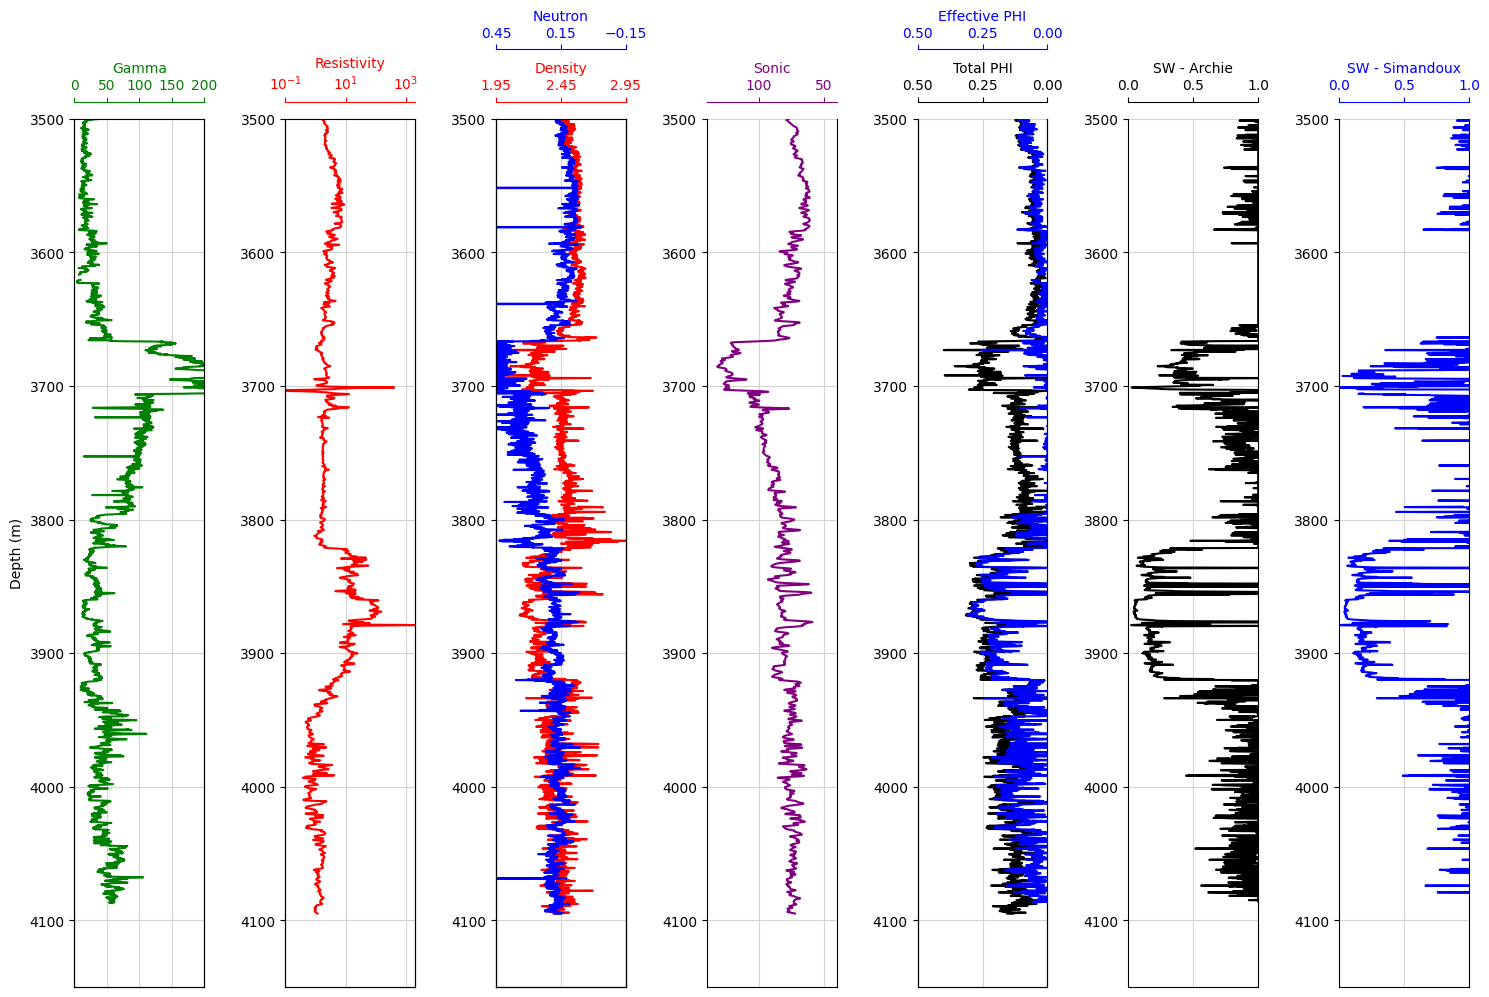

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))

#Set up the plot axes
ax1 = plt.subplot2grid((1,7), (0,0), rowspan=1, colspan = 1)
ax2 = plt.subplot2grid((1,7), (0,1), rowspan=1, colspan = 1)
ax3 = plt.subplot2grid((1,7), (0,2), rowspan=1, colspan = 1)
ax4 = plt.subplot2grid((1,7), (0,3), rowspan=1, colspan = 1)
ax5 = ax3.twiny() #Twins the y-axis for the density track with the neutron track
ax6 = plt.subplot2grid((1,7), (0,4), rowspan=1, colspan = 1)
ax7 = ax6.twiny()
ax8 = plt.subplot2grid((1,7), (0,5), rowspan=1, colspan = 1)
ax9 = plt.subplot2grid((1,7), (0,6), rowspan=1, colspan = 1)

# As our curve scales will be detached from the top of the track,
# this code adds the top border back in without dealing with splines
ax10 = ax1.twiny()
ax10.xaxis.set_visible(False)
ax11 = ax2.twiny()
ax11.xaxis.set_visible(False)
ax12 = ax3.twiny()
ax12.xaxis.set_visible(False)

# Gamma Ray track
ax1.plot("GR", "DEPTH", data = well, color = "green")
ax1.set_xlabel("Gamma")
ax1.xaxis.label.set_color("green")
ax1.set_xlim(0, 200)
ax1.set_ylabel("Depth (m)")
ax1.tick_params(axis='x', colors="green")
ax1.spines["top"].set_edgecolor("green")
ax1.title.set_color('green')
ax1.set_xticks([0, 50, 100, 150, 200])

# Resistivity track
ax2.plot("RT", "DEPTH", data = well, color = "red")
ax2.set_xlabel("Resistivity")
ax2.set_xlim(0.2, 2000)
ax2.xaxis.label.set_color("red")
ax2.tick_params(axis='x', colors="red")
ax2.spines["top"].set_edgecolor("red")
ax2.set_xticks([0.1, 1, 10, 100, 1000])
ax2.semilogx()

# Density track
ax3.plot("RHOB", "DEPTH", data = well, color = "red")
ax3.set_xlabel("Density")
ax3.set_xlim(1.95, 2.95)
ax3.xaxis.label.set_color("red")
ax3.tick_params(axis='x', colors="red")
ax3.spines["top"].set_edgecolor("red")
ax3.set_xticks([1.95, 2.45, 2.95])

# Sonic track
ax4.plot("DT", "DEPTH", data = well, color = "purple")
ax4.set_xlabel("Sonic")
ax4.set_xlim(140, 40)
ax4.xaxis.label.set_color("purple")
ax4.tick_params(axis='x', colors="purple")
ax4.spines["top"].set_edgecolor("purple")

# Neutron track placed ontop of density track
ax5.plot("NPHI", "DEPTH", data = well, color = "blue")
ax5.set_xlabel('Neutron')
ax5.xaxis.label.set_color("blue")
ax5.set_xlim(0.45, -0.15)
ax5.set_ylim(4150, 3500)
ax5.tick_params(axis='x', colors="blue")
ax5.spines["top"].set_position(("axes", 1.08))
ax5.spines["top"].set_visible(True)
ax5.spines["top"].set_edgecolor("blue")
ax5.set_xticks([0.45,  0.15, -0.15])

# Porosity track
ax6.plot("PHI", "DEPTH", data = well, color = "black")
ax6.set_xlabel("Total PHI")
ax6.set_xlim(0.5, 0)
ax6.xaxis.label.set_color("black")
ax6.tick_params(axis='x', colors="black")
ax6.spines["top"].set_edgecolor("black")
ax6.set_xticks([0, 0.25, 0.5])

# Effective Porosity track
ax7.plot("PHIECALC", "DEPTH", data = well, color = "blue")
ax7.set_xlabel("Effective PHI")
ax7.set_xlim(0.5, 0)
ax7.xaxis.label.set_color("blue")
ax7.tick_params(axis='x', colors="blue")
ax7.spines["top"].set_position(("axes", 1.08))
ax7.spines["top"].set_visible(True)
ax7.spines["top"].set_edgecolor("blue")
ax7.set_xticks([0, 0.25, 0.5])

# Sw track
ax8.plot("SW_LIM", "DEPTH", data = well, color = "black")
ax8.set_xlabel("SW - Archie")
ax8.set_xlim(0, 1)
ax8.xaxis.label.set_color("black")
ax8.tick_params(axis='x', colors="black")
ax8.spines["top"].set_edgecolor("black")
ax8.set_xticks([0, 0.5, 1])

# Sw track
ax9.plot("SW_SIM", "DEPTH", data = well, color = "blue")
ax9.set_xlabel("SW - Simandoux")
ax9.set_xlim(0, 1)
ax9.xaxis.label.set_color("blue")
ax9.tick_params(axis='x', colors="blue")
ax9.spines["top"].set_edgecolor("blue")
ax9.set_xticks([0, 0.5, 1])

# Common functions for setting up the plot can be extracted into
# a for loop. This saves repeating code.
for ax in [ax1, ax2, ax3, ax4, ax6, ax8, ax9]:
    ax.set_ylim(4150, 3500)
    ax.grid(which='major', color='lightgrey', linestyle='-')
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.spines["top"].set_position(("axes", 1.02))


plt.tight_layout()
fig.savefig('Final_log.jpg')


## Net Pay Estimation & Formation Evaluation

Porosity and saturation are **fractions** (0.21 = 21%). Cutoffs:
sand if $V_{sh} < 0.4$, reservoir if $\phi_e > 0.08$, pay if $S_w < 0.6$.


In [ ]:
# --- Net Pay Estimation (step 7) ---
VSH_CUT = 0.4      # sand if shale volume below this
PHI_CUT = 0.08     # reservoir if effective porosity above this
SW_CUT  = 0.6      # pay if water saturation below this
STEP    = 0.1524   # metres per depth sample

well['SAND'] = well['VSHALE'] < VSH_CUT
well['RES']  = well['PHIECALC'] > PHI_CUT
well['PAY']  = well['SAND'] & well['RES'] & (well['SW_LIM'] < SW_CUT)

# NOTE: this is the LOGGED INTERVAL (mostly shale), not 'gross rock'.
# Every thickness below is MEASURED DEPTH (MD), not TVD -- 15/9-19 SR
# is a sidetrack, so true vertical thickness is less.
logged  = well['DEPTH'].max() - well['DEPTH'].min()
net_res = well['RES'].sum() * STEP
net_pay = well['PAY'].sum() * STEP

print(f"Logged interval = {logged:8.1f} m (MD)")
print(f"Net reservoir   = {net_res:8.1f} m (MD)")
print(f"Net pay         = {net_pay:8.1f} m (MD)")


In [ ]:
# --- Contiguous Net-Pay Zones + Formation Evaluation (step 8) ---
zones = []
top = None
for i in range(len(well)):
    pay = well['PAY'].iloc[i]
    depth = well['DEPTH'].iloc[i]
    if pay and top is None:
        top = depth
    elif not pay and top is not None:
        base = depth - STEP
        # thickness = n_samples * STEP. Using (base - top) drops one sample per
        # zone, which made the table sum to 90.2 m against a net pay of 94.3 m
        # and printed single-sample zones as "0.00 m".
        zones.append((top, base, base - top + STEP))
        top = None
if top is not None:
    last = well['DEPTH'].iloc[-1]
    zones.append((top, last, last - top + STEP))

print(f"Found {len(zones)} contiguous pay zones:")
for n, (top, base, thick) in enumerate(zones, 1):
    print(f"  zone {n:2d}: {top:8.1f} - {base:8.1f} m   {thick:6.2f} m")

# --- Formation evaluation report ---
pay = well['PAY']
print()
print("=== FORMATION EVALUATION --- well 15/9-19 ===")
print(f"Net pay          = {net_pay:.1f} m in {len(zones)} zones")
print(f"Mean PHIE in pay = {well.loc[pay, 'PHIECALC'].mean():.3f}  (fraction)")
print(f"Mean SW   in pay = {well.loc[pay, 'SW_LIM'].mean():.3f}  (fraction)")
well.to_csv("results.csv")
print("Saved results.csv")


## Sensitivity Check --- Which Porosity Goes Into Archie?

Above, `SW` was computed from **`PHI`** (total density porosity):

```python
well['SW'] = sw_archie(well['PHI'], well['RT'], well['RW'], 1, 2, 2)
```

But the net-pay cutoff uses **`PHIECALC`** (effective porosity). Archie can be run on
either one, and the choice is a *petrophysical* decision, not a coding one:

- **Total porosity `PHI`** --- includes clay-bound water. Common with the standard
  Archie constants.
- **Effective porosity `PHIE`** --- excludes clay-bound water. Consistent with the
  `PHIE > 0.08` reservoir cutoff used below.

Since $S_w \propto 1/\phi$, the smaller `PHIE` gives a **higher** $S_w$, so fewer
samples pass `SW < 0.6`. Run the next cell to see how much net pay hangs on this
one choice.

In [ ]:
# --- Sensitivity: total vs effective porosity in Archie ---
# Same data, same cutoffs, same a/m/n. Only the porosity fed to Archie changes.
for name, phi in [('PHI  (total)    ', well['PHI']),
                  ('PHIE (effective)', well['PHIECALC'])]:
    sw  = sw_archie(phi, well['RT'], well['RW'], 1, 2, 2)
    sw  = sw.mask(sw > 1, 1)
    pay = ((well['VSHALE'] < VSH_CUT)
           & (well['PHIECALC'] > PHI_CUT)
           & (sw < SW_CUT))

    # count contiguous pay zones
    n_zones = int((pay & ~pay.shift(1, fill_value=False)).sum())

    print(f"{name} -> net pay {pay.sum() * STEP:6.1f} m "
          f"in {n_zones:3d} zones,  mean SW in pay = {sw[pay].mean():.3f}")

print()
print("Neither is a bug. Decide which one your report uses -- and write it down.")

# --- Log resolution: is a 0.15 m "zone" a zone? ---
# The density log resolves ~0.3-0.45 m. Zones thinner than that are single
# samples, not geology. Re-count the base case with a minimum thickness.
thick = []
top = None
for i in range(len(well)):
    p, d = well['PAY'].iloc[i], well['DEPTH'].iloc[i]
    if p and top is None:
        top = d
    elif not p and top is not None:
        thick.append(d - STEP - top + STEP)
        top = None
if top is not None:
    thick.append(well['DEPTH'].iloc[-1] - top + STEP)
thick = np.array(thick)

print()
for cut in [0.0, 0.5, 1.0]:
    keep = thick >= cut
    print(f"min zone thickness {cut:.1f} m -> {keep.sum():3d} zones, "
          f"{thick[keep].sum():6.1f} m net pay")
print()
print("Same rock. The thickness is robust; the zone COUNT is an artefact of resolution.")


# Functions and signal processing parts

*           f ( t ) = A sin( ω t + ρ )*

*t* = time (s)
*A* = Amplitude
*ω* = Angular frequency (Hz)

please note that *ω*= *2.Pi. Freq.*

*ρ* = phase shift

Ref: https://www.youtube.com/watch?app=desktop&v=oEIFHIWgzvI
( Digital Signal Processing with Dr. Aaron Velasco)

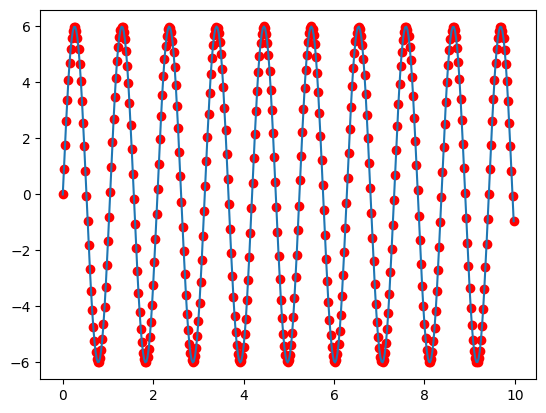

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, fft  # For conducting signal processing (https://www.scipy.org/)
import math
# Given
sps1 = 40                    # Samples per second (sample rate).
t1 = np.arange(0, 10, 1/sps1)  # Create an time array from 0-10 for given sample rate.
A1 = 6                       # Amplitude
omega1 = 6                   # Angular Frequency where w=2. pi . Freq ( it means that the frequency can be estimated = w/(2.pi))
phi = 0                    # Phase Shift
y1 = A1 * np.sin(omega1 * t1 +phi) # Calculate sine function
plt.plot(t1,y1)
plt.scatter(t1,y1,color='red')

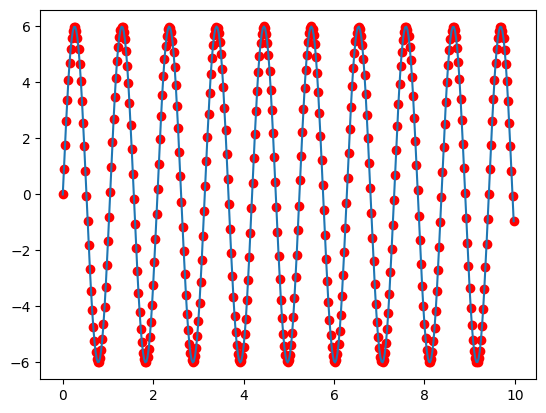

In [ ]:
def sine_wave(sample_rate,omega,phi,Amp):
  t1 = np.arange(0, 10, 1/sample_rate)
  y1 = Amp * np.sin(omega * t1 +phi)
  plt.plot(t1,y1)
  a=plt.scatter(t1,y1,color='red')
  return a

sine_wave(40,6,0,6)

In [ ]:
wave_duration = 3 # Time will be presented in X-axis
sample_rate = 100 # No of samples or readings per second
freq = 4 # No of complete viberations per second (Remember that the nyquest frequency will be half of this freqyency)
q = 2 # We will down sample to half of the current sampling rate (50)
samples = wave_duration*sample_rate # No of samples can be estiamted by multiply duration* sampling_rate (300)
samples_decimated = int(samples/q)# No of samples after down sampling
x = np.linspace(0, wave_duration, samples, endpoint=False) #remember down np.linspace will take begin, end and nuber of samples not the step.
y = np.cos(x*np.pi*freq*2)
ydem = signal.decimate(y, q)
xdem = signal.decimate(x, q)

Plotting before re-sampling




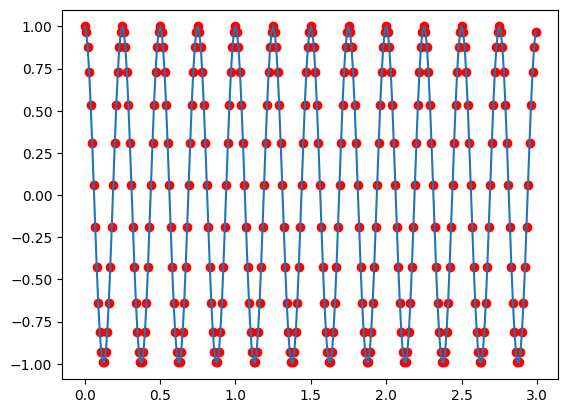

In [ ]:
plt.plot(x,y)
plt.scatter(x,y,color='red')

**`Plotting after resampling`**

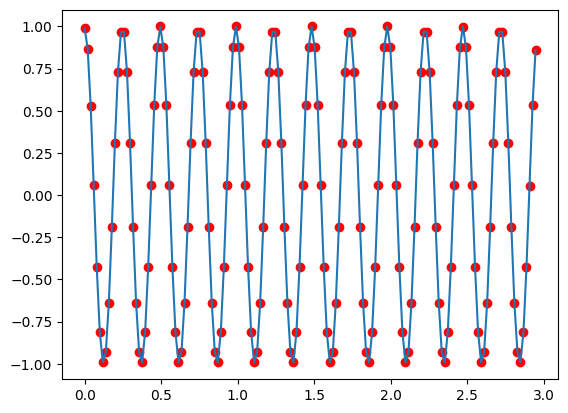

In [ ]:
plt.plot(xdem,ydem)
plt.scatter(xdem,ydem,color='red')

Another way of down sampling

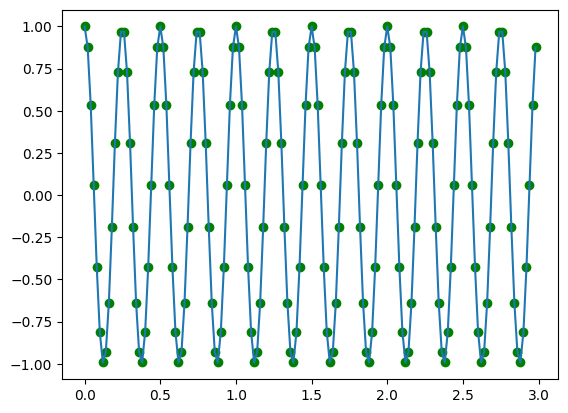

In [ ]:
dec_factor1 = 2             # Decimation Factor
y_dec1 = y[::dec_factor1]  # Decimate signal
x_dec1 = x[::dec_factor1]  # Resample time to match decimated signal
plt.plot(x_dec1,y_dec1)
plt.scatter(x_dec1,y_dec1, color='green')

**Generating 3 cosine signals**

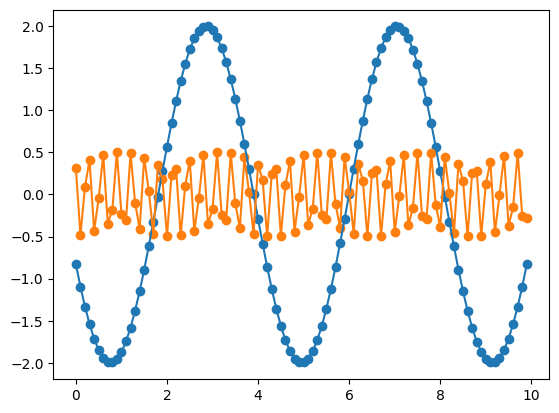

In [ ]:
sps2 = 10                    # Samples per second (sample rate).
t2 = np.arange(0, 10, 1/sps2)  # Create an array from 0-10 for given sample rate.

y2_a = 2 * np.cos(1.5 * t2 + 2)
y2_b = 0.5 * np.cos(20 * t2 + 0.9)
y2_b1 = 5 * np.cos(4 * t2 + 0)

y2_ab = np.add(y2_a, y2_b)
yyy=np.add(y2_ab,y2_b1)# or y2_a + y2_b but using numpy is usually faster and safer.
plt.scatter(t2,y2_a)
plt.plot(t2,y2_a)
plt.scatter(t2,y2_b)
plt.plot(t2,y2_b)

Example of Fourier Transform using Plotly (interactive plot)

In [ ]:
import plotly.graph_objects as go  # Plotly for interactive figure creation (https://plotly.com/python/).
from plotly.subplots import make_subplots
def fourier_demo():
    # number of signal points
    N = 500

    # sample spacing
    T = 1/1000

    x = np.linspace(0.0, N*T, N, endpoint=False)

    y = (10 * np.sin(30 * 2.0*np.pi*x) +
         1 * np.sin(40 * 2.0*np.pi*x) +
         3 * np.sin(65 * 2.0*np.pi*x) +
         3 * np.sin(75 * 2.0*np.pi*x))
    plot_y = (10 * np.sin(30 * x) + 1 * np.sin(40 * x) + 3 * np.sin(65 * x) + 3 * np.sin(75 * x))
    yf = fft.fft(y)
    xf = fft.fftfreq(N, T)
    xf = fft.fftshift(xf)

    yplot = fft.fftshift(yf)


    fig = go.Figure()
    fig.add_trace(go.Scatter(y=plot_y, x=x % 360, mode='lines'))
    fig.update_layout(title='<b>Waveform (Time Domain)</b>')
    fig.update_xaxes(title_text='Time (s)')
    fig.update_yaxes(title_text='Amplitude')
    fig.show()

    fig = go.Figure()
    fig.add_trace(go.Scatter(y=(1.0/N*np.abs(yplot))*2, x=xf, mode='lines'))
    fig.update_layout(title='<b> Power Spectrum (Frequency Domain)</b>', xaxis=dict(range=[0, N]))
    fig.update_xaxes(title_text='Frequency (Hz)')
    fig.update_yaxes(title_text='Amplitude')
    fig.show()
# number of signal points
N = 500

# sample spacing
T = 1/1000

x = np.linspace(0.0, N*T, N, endpoint=False)

y = (10 * np.sin(30 * 2.0*np.pi*x) +
      1 * np.sin(40 * 2.0*np.pi*x) +
      3 * np.sin(65 * 2.0*np.pi*x) +
      3 * np.sin(75 * 2.0*np.pi*x))
plot_y = (10 * np.sin(30 * x) + 1 * np.sin(40 * x) + 3 * np.sin(65 * x) + 3 * np.sin(75 * x))
yf = fft.fft(y)
xf = fft.fftfreq(N, T)
xf = fft.fftshift(xf)

yplot = fft.fftshift(yf)


fig = go.Figure()
fig.add_trace(go.Scatter(y=plot_y, x=x % 360, mode='lines'))
fig.update_layout(title='<b>Waveform (Time Domain)</b>')
fig.update_xaxes(title_text='Time (s)')
fig.update_yaxes(title_text='Amplitude')
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(y=(1.0/N*np.abs(yplot))*2, x=xf, mode='lines'))
fig.update_layout(title='<b> Power Spectrum (Frequency Domain)</b>', xaxis=dict(range=[0, N]))
fig.update_xaxes(title_text='Frequency (Hz)')
fig.update_yaxes(title_text='Amplitude')
fig.show()